In [1]:
# Connect to your Google Drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# Change this path if your camp folder is somewhere else.
%cd /content/drive/MyDrive/Everything USF/AI Summer Intensive 2026/Day 2

/content/drive/MyDrive/Everything USF/DRAFT AI Summer Camp/Group project -- template code


In [5]:
df = pd.read_csv("data/seoul_bike_demand.csv",parse_dates=["date"])
df.head()

,datetime,date,hour,time_period,day_of_week,month,is_weekend,season,is_holiday,weather_condition,temperature_c,humidity_percent,wind_speed_m_s,visibility_m,solar_radiation_mj_m2,rainfall_mm,snowfall_cm,rented_bike_count
0,2017-12-01 00:00:00,2017-12-01,0,Night,Friday,12,0,Winter,0,Dry,-5.2,37,2.2,20000,0.0,0.0,0.0,254
1,2017-12-01 01:00:00,2017-12-01,1,Night,Friday,12,0,Winter,0,Dry,-5.5,38,0.8,20000,0.0,0.0,0.0,204
2,2017-12-01 02:00:00,2017-12-01,2,Night,Friday,12,0,Winter,0,Dry,-6.0,39,1.0,20000,0.0,0.0,0.0,173
3,2017-12-01 03:00:00,2017-12-01,3,Night,Friday,12,0,Winter,0,Dry,-6.2,40,0.9,20000,0.0,0.0,0.0,107
4,2017-12-01 04:00:00,2017-12-01,4,Night,Friday,12,0,Winter,0,Dry,-6.0,36,2.3,20000,0.0,0.0,0.0,78


In [6]:
print(f"Total rows: {len(df)}")

Total rows: 8465


# Exploratory Data Analysis

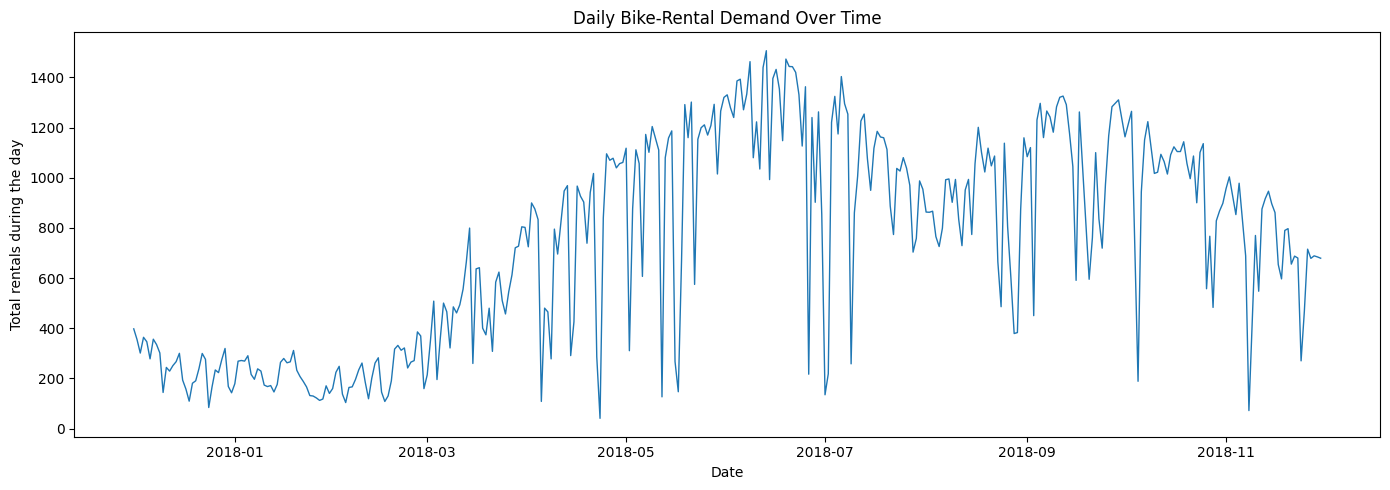

In [8]:
plt.figure(figsize=(14, 5))

sns.lineplot(
    x="date",
    y="rented_bike_count",
    data=df,
    errorbar = None, # Remove error bars
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Total rentals during the day")
plt.title("Daily Bike-Rental Demand Over Time")
plt.tight_layout()
plt.show()

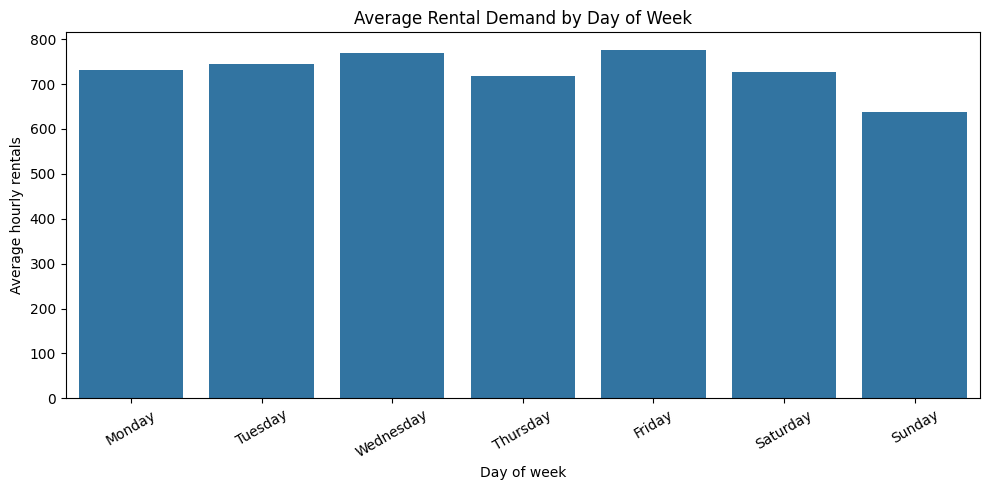

In [10]:
plt.figure(figsize=(10, 5))

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

sns.barplot(
    x="day_of_week",
    y="rented_bike_count",
    data=df,
    estimator= "mean", # Seaborn will calculate the mean for each day
    errorbar = None, # Remove error bars
    order=weekday_order, # Ensure the days are in the correct order
)

plt.xlabel("Day of week")
plt.ylabel("Average hourly rentals")
plt.title("Average Rental Demand by Day of Week")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

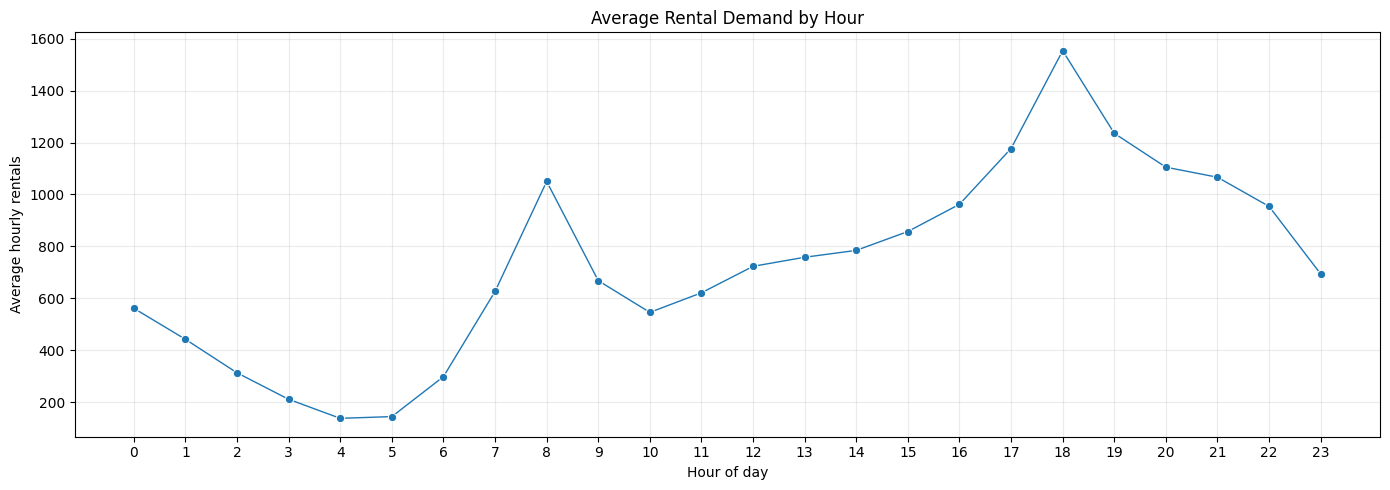

In [15]:
plt.figure(figsize=(14, 5))

sns.lineplot(
    x="hour",
    y="rented_bike_count",
    data=df,
    errorbar = None, # Remove error bars
    linewidth=1,
    marker="o",
)

plt.xlabel("Hour of day")
plt.ylabel("Average hourly rentals")
plt.title("Average Rental Demand by Hour")
plt.xticks(
    range(0, 24)
)
plt.grid(
    alpha=0.25
)
plt.tight_layout()
plt.show()

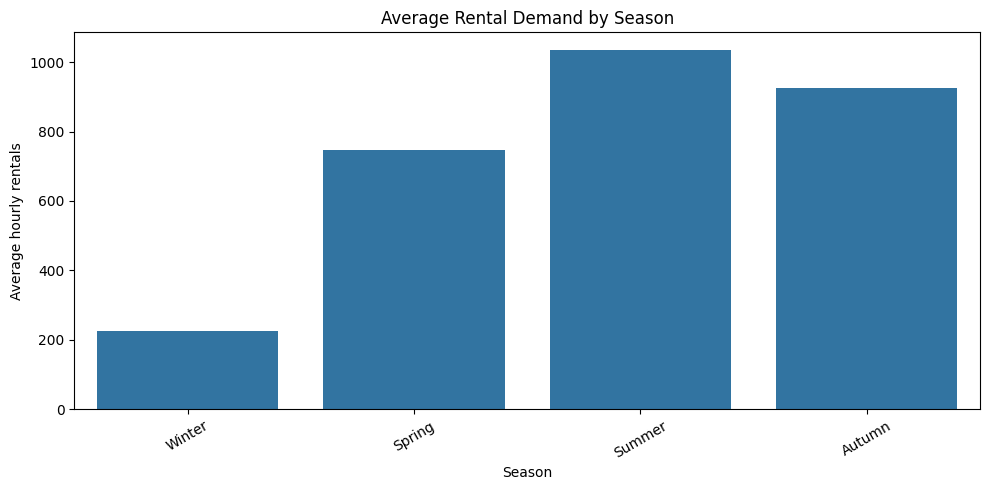

In [16]:
plt.figure(figsize=(10, 5))

season_order = [
    "Winter",
    "Spring",
    "Summer",
    "Autumn",
]

sns.barplot(
    x="season",
    y="rented_bike_count",
    data=df,
    estimator= "mean", # Seaborn will calculate the mean for each day
    errorbar = None, # Remove error bars
    order=season_order, # Ensure the days are in the correct order
)

plt.xlabel("Season")
plt.ylabel("Average hourly rentals")
plt.title("Average Rental Demand by Season")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

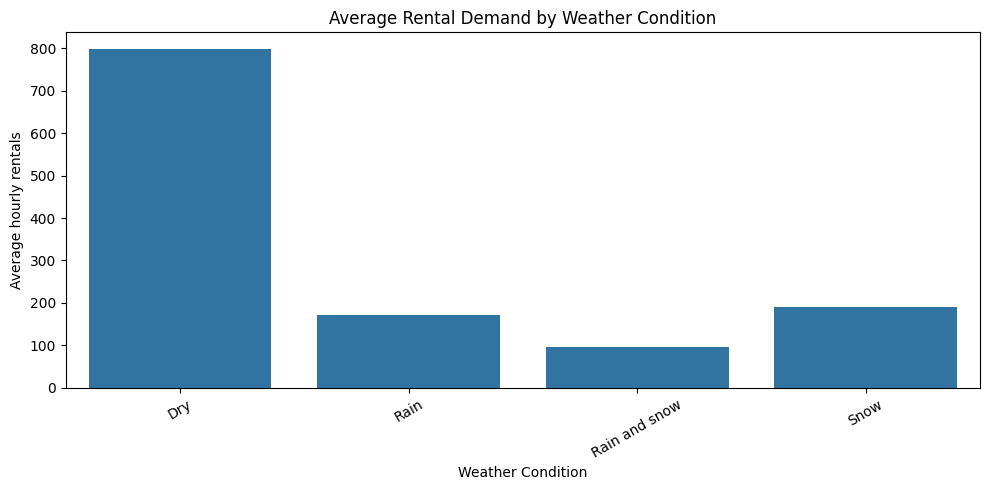

In [19]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x="weather_condition",
    y="rented_bike_count",
    data=df,
    estimator= "mean", # Seaborn will calculate the mean for each day
    errorbar = None, # Remove error bars
)

plt.xlabel("Weather Condition")
plt.ylabel("Average hourly rentals")
plt.title("Average Rental Demand by Weather Condition")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

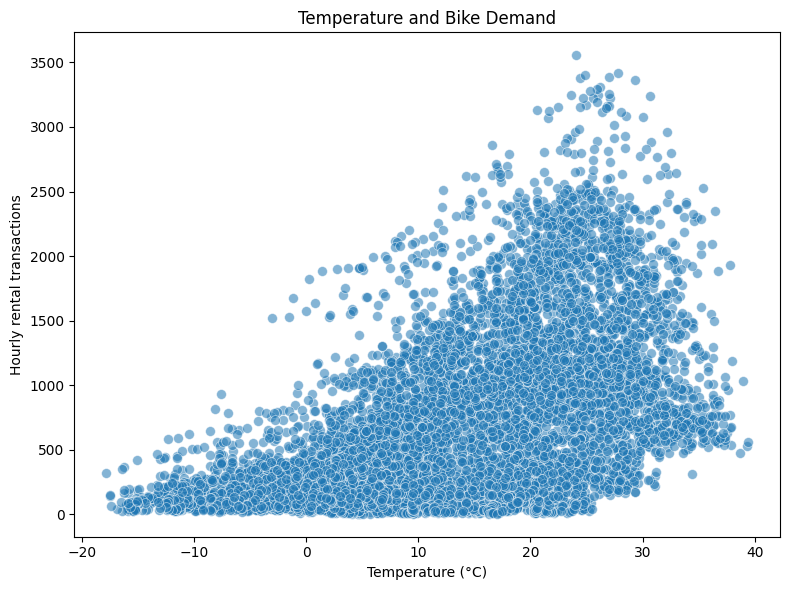

In [24]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="temperature_c",
    y="rented_bike_count",
    data=df,
    alpha=0.55, # Adjust transparency for overlapping points
    s=50,       # Adjust point size
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Hourly rental transactions")
plt.title("Temperature and Bike Demand")
plt.tight_layout()
plt.show()

# Linear Regression

In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

## Preparing the Dataset

In [25]:
features_list = ['temperature_c']
target = 'rented_bike_count'

In [26]:
X = df[features_list]
X

,temperature_c
0,-5.2
1,-5.5
2,-6.0
3,-6.2
4,-6.0
...,...
8460,4.2
8461,3.4
8462,2.6
8463,2.1


In [27]:
y = df[target]
y

,rented_bike_count
0,254
1,204
2,173
3,107
4,78
...,...
8460,1003
8461,764
8462,694
8463,712


In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
print(f"Total training data points: {len(X_train)}")
print(f"Total testing data points: {len(X_test)}")

Total training data points: 6772
Total testing data points: 1693


In [30]:
def prepare_dataset(df, feature_list,target):
  X = df[feature_list].copy()
  y = df[target].copy()
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
  return X_train, X_test, y_train, y_test

In [31]:
features_list = ['temperature_c']
target = 'rented_bike_count'
X_train, X_test, y_train, y_test = prepare_dataset(df, features_list, target)
print(f"Total training data points: {len(X_train)}")
print(f"Total testing data points: {len(X_test)}")

Total training data points: 6772
Total testing data points: 1693


## Fitting the Model to the Training Data

In [32]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [33]:
def train_model(X_train, y_train):
  model = LinearRegression()
  model.fit(X_train, y_train)
  return model

In [34]:
model = train_model(X_train, y_train)

In [35]:
print(f"Model Coefficient (slope): {model.coef_[0]:.2f}")
print(f"Model Intercept: {model.intercept_:.2f}")

Model Coefficient (slope): 30.08
Model Intercept: 346.62


## Evaluating the Fitted Model using Test Data

In [36]:
y_pred = model.predict(X_test)

In [37]:
# Create a DataFrame with actual and predicted values
results_df = pd.DataFrame({
    'Actual': y_test.round(2),
    'Predicted': y_pred.round(2)
})

# Display the top 10 rows
results_df['Error'] = (results_df['Actual'] - results_df['Predicted']).abs().round(2)
results_df.head(10)

,Actual,Predicted,Error
5945,1232,1417.36,185.36
5292,964,1191.79,227.79
5903,942,1212.84,270.84
879,373,415.80,42.80
6861,1259,1089.52,169.48
5723,476,1357.21,881.21
4885,1062,1266.98,204.98
1452,253,250.37,2.63
7170,2857,845.90,2011.10
8170,1039,608.29,430.71


In [38]:
mae = mean_absolute_error(y_test, y_pred)
mae

381.238502216127

R² tells us how much of the variance in the actual values the model is able to explain.

R² = 1 → Perfect model

R² = 0 → Model predicts no better than the average

R² < 0 → Model is worse than guessing

In [39]:
r2 = r2_score(y_test, y_pred)
r2

0.32488243123316574

In [40]:
def evaluate_model(model, X_test, y_test):
  y_pred = model.predict(X_test)
  mae = mean_absolute_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  print(f"Mean Absolute Error on Test Set: {mae:.2f}")
  print(f"R-squared on Test Set: {r2:.2f}")
  return y_pred

In [41]:
y_pred = evaluate_model(model, X_test, y_test)

Mean Absolute Error on Test Set: 381.24
R-squared on Test Set: 0.32


## Plotting the Fitted Line

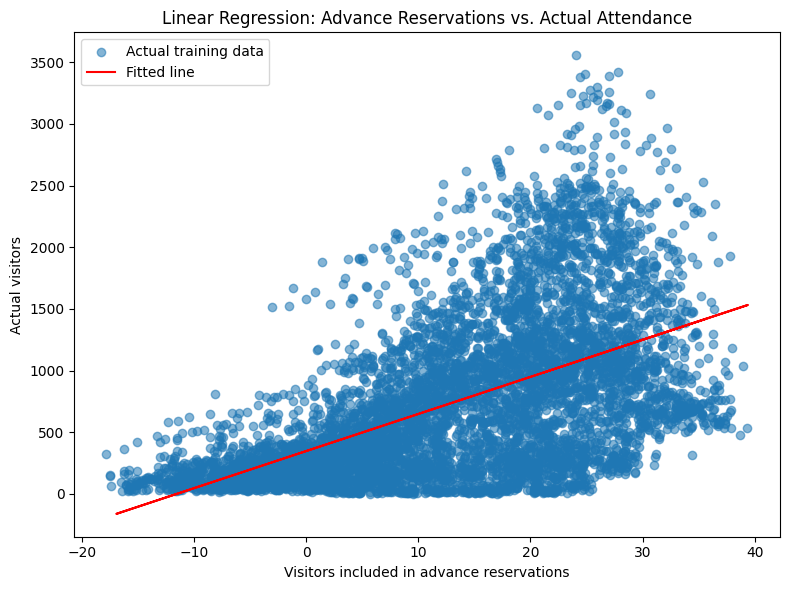

In [42]:
# Plot the fitted line
plt.figure(figsize=(8, 6))
plt.scatter(X_train, y_train, alpha=0.55, label='Actual training data')
plt.plot(X_test, y_pred, color='red', label='Fitted line')

plt.xlabel("Visitors included in advance reservations")
plt.ylabel("Actual visitors")
plt.title("Linear Regression: Advance Reservations vs. Actual Attendance")
plt.legend()
plt.tight_layout()
plt.show()

# Fitting a Model with Multiple Input Features

In [44]:
features_list = ['temperature_c','wind_speed_m_s']
target = 'rented_bike_count'

X_train, X_test, y_train, y_test = prepare_dataset(df, features_list, target)

model = train_model(X_train,y_train)

y_pred = evaluate_model(model, X_test, y_test)

Mean Absolute Error on Test Set: 372.95
R-squared on Test Set: 0.35


In [45]:
features_list = ['temperature_c','wind_speed_m_s','humidity_percent']
target = 'rented_bike_count'

X_train, X_test, y_train, y_test = prepare_dataset(df, features_list, target)

model = train_model(X_train,y_train)

y_pred = evaluate_model(model, X_test, y_test)

Mean Absolute Error on Test Set: 353.81
R-squared on Test Set: 0.41


In [47]:
features_list = ['temperature_c','wind_speed_m_s','humidity_percent','rainfall_mm','snowfall_cm']
target = 'rented_bike_count'

X_train, X_test, y_train, y_test = prepare_dataset(df, features_list, target)

model = train_model(X_train,y_train)

y_pred = evaluate_model(model, X_test, y_test)

Mean Absolute Error on Test Set: 350.43
R-squared on Test Set: 0.42


In [48]:
features_list = ['temperature_c','wind_speed_m_s','humidity_percent','rainfall_mm','snowfall_cm','is_holiday','is_weekend','month']
target = 'rented_bike_count'

X_train, X_test, y_train, y_test = prepare_dataset(df, features_list, target)

model = train_model(X_train,y_train)

y_pred = evaluate_model(model, X_test, y_test)

Mean Absolute Error on Test Set: 346.05
R-squared on Test Set: 0.43


In [49]:
features_list = ['temperature_c','wind_speed_m_s','humidity_percent','rainfall_mm','snowfall_cm','is_holiday','is_weekend','month','hour']
target = 'rented_bike_count'

X_train, X_test, y_train, y_test = prepare_dataset(df, features_list, target)

model = train_model(X_train,y_train)

y_pred = evaluate_model(model, X_test, y_test)

Mean Absolute Error on Test Set: 328.61
R-squared on Test Set: 0.53


# One-hot Encoding

In [ ]:
# def prepare_dataset(df, feature_list,target):
#   X = df[feature_list].copy()
#   y = df[target].copy()
#   X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#   return X_train, X_test, y_train, y_test

In [50]:
df.head()

,datetime,date,hour,time_period,day_of_week,month,is_weekend,season,is_holiday,weather_condition,temperature_c,humidity_percent,wind_speed_m_s,visibility_m,solar_radiation_mj_m2,rainfall_mm,snowfall_cm,rented_bike_count
0,2017-12-01 00:00:00,2017-12-01,0,Night,Friday,12,0,Winter,0,Dry,-5.2,37,2.2,20000,0.0,0.0,0.0,254
1,2017-12-01 01:00:00,2017-12-01,1,Night,Friday,12,0,Winter,0,Dry,-5.5,38,0.8,20000,0.0,0.0,0.0,204
2,2017-12-01 02:00:00,2017-12-01,2,Night,Friday,12,0,Winter,0,Dry,-6.0,39,1.0,20000,0.0,0.0,0.0,173
3,2017-12-01 03:00:00,2017-12-01,3,Night,Friday,12,0,Winter,0,Dry,-6.2,40,0.9,20000,0.0,0.0,0.0,107
4,2017-12-01 04:00:00,2017-12-01,4,Night,Friday,12,0,Winter,0,Dry,-6.0,36,2.3,20000,0.0,0.0,0.0,78


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8465 entries, 0 to 8464
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   datetime               8465 non-null   object        
 1   date                   8465 non-null   datetime64[ns]
 2   hour                   8465 non-null   int64         
 3   time_period            8465 non-null   object        
 4   day_of_week            8465 non-null   object        
 5   month                  8465 non-null   int64         
 6   is_weekend             8465 non-null   int64         
 7   season                 8465 non-null   object        
 8   is_holiday             8465 non-null   int64         
 9   weather_condition      8465 non-null   object        
 10  temperature_c          8465 non-null   float64       
 11  humidity_percent       8465 non-null   int64         
 12  wind_speed_m_s         8465 non-null   float64       
 13  vis

In [57]:
season_one_hot_encoded = pd.get_dummies(df,columns=['season'],dtype=int)
season_one_hot_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8465 entries, 0 to 8464
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   datetime               8465 non-null   object        
 1   date                   8465 non-null   datetime64[ns]
 2   hour                   8465 non-null   int64         
 3   time_period            8465 non-null   object        
 4   day_of_week            8465 non-null   object        
 5   month                  8465 non-null   int64         
 6   is_weekend             8465 non-null   int64         
 7   is_holiday             8465 non-null   int64         
 8   weather_condition      8465 non-null   object        
 9   temperature_c          8465 non-null   float64       
 10  humidity_percent       8465 non-null   int64         
 11  wind_speed_m_s         8465 non-null   float64       
 12  visibility_m           8465 non-null   int64         
 13  sol

In [58]:
season_one_hot_encoded.head()

,datetime,date,hour,time_period,day_of_week,month,is_weekend,is_holiday,weather_condition,temperature_c,...,wind_speed_m_s,visibility_m,solar_radiation_mj_m2,rainfall_mm,snowfall_cm,rented_bike_count,season_Autumn,season_Spring,season_Summer,season_Winter
0,2017-12-01 00:00:00,2017-12-01,0,Night,Friday,12,0,0,Dry,-5.2,...,2.2,20000,0.0,0.0,0.0,254,0,0,0,1
1,2017-12-01 01:00:00,2017-12-01,1,Night,Friday,12,0,0,Dry,-5.5,...,0.8,20000,0.0,0.0,0.0,204,0,0,0,1
2,2017-12-01 02:00:00,2017-12-01,2,Night,Friday,12,0,0,Dry,-6.0,...,1.0,20000,0.0,0.0,0.0,173,0,0,0,1
3,2017-12-01 03:00:00,2017-12-01,3,Night,Friday,12,0,0,Dry,-6.2,...,0.9,20000,0.0,0.0,0.0,107,0,0,0,1
4,2017-12-01 04:00:00,2017-12-01,4,Night,Friday,12,0,0,Dry,-6.0,...,2.3,20000,0.0,0.0,0.0,78,0,0,0,1


In [59]:
categorical_columns = df.select_dtypes(include=["object"]).columns
categorical_columns

Index(['datetime', 'time_period', 'day_of_week', 'season',
       'weather_condition'],
      dtype='object')

In [61]:
def prepare_dataset_v2(df, feature_list, target):
    X = df[feature_list].copy()
    y = df[target].copy()

    # Find every text/categorical feature automatically
    categorical_columns = X.select_dtypes(include=["object"]).columns

    # One-hot encode those columns; numerical columns stay unchanged
    X = pd.get_dummies(X,columns=categorical_columns,dtype=int)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    return X_train, X_test, y_train, y_test

In [62]:
features_list = ['temperature_c','wind_speed_m_s','humidity_percent','rainfall_mm','snowfall_cm','is_holiday','is_weekend','month','hour','season','weather_condition']
target = 'rented_bike_count'

X_train, X_test, y_train, y_test = prepare_dataset_v2(df, features_list, target)

model = train_model(X_train,y_train)

y_pred = evaluate_model(model, X_test, y_test)

Mean Absolute Error on Test Set: 315.41
R-squared on Test Set: 0.57


In [63]:
features_list = ['temperature_c','wind_speed_m_s','humidity_percent','rainfall_mm','snowfall_cm','is_holiday','is_weekend','month',
                 'hour','season','weather_condition','day_of_week']
target = 'rented_bike_count'

X_train, X_test, y_train, y_test = prepare_dataset_v2(df, features_list, target)

model = train_model(X_train,y_train)

y_pred = evaluate_model(model, X_test, y_test)

Mean Absolute Error on Test Set: 314.46
R-squared on Test Set: 0.57


In [64]:
def train_model_v2(X_train, y_train):
  model = RandomForestRegressor()
  model.fit(X_train, y_train)
  return model

In [67]:
features_list = ['temperature_c','wind_speed_m_s','humidity_percent','rainfall_mm','snowfall_cm','is_holiday','is_weekend','month',
                 'hour','season','weather_condition','day_of_week']
target = 'rented_bike_count'

X_train, X_test, y_train, y_test = prepare_dataset_v2(df, features_list, target)

model = train_model_v2(X_train,y_train)

y_pred = evaluate_model(model, X_test, y_test)

Mean Absolute Error on Test Set: 95.80
R-squared on Test Set: 0.92
